# Crop Health Monitoring — Setup & Training

**Author:** Khang Phan  
**Purpose:** Download the PlantVillage dataset, explore it critically, and train both models.

This notebook:
1. Checks that all dependencies are installed
2. Downloads PlantVillage (15 classes, 3 crops: Tomato / Potato / Pepper)
3. Explores class distribution and imbalance (21x ratio — important for evaluation)
4. Trains a ResNet-18 disease classifier (the academic center of this project)
5. Evaluates **per-class accuracy** and plots a confusion matrix
6. Trains an XGBoost environmental risk model (decision-support layer — derived target)
7. Saves both models to `results/`

**Scope:** Lab-controlled PlantVillage images only. 3 crops, 15 classes, ~41,000 images.  
Field performance will differ — see the lab-to-field caveat in Section 9.

## 1. Environment Check

In [1]:
import importlib.metadata, sys

# Maps pip package name → import name (for display)
packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scikit-learn": "sklearn",
    "xgboost": "xgboost",
    "torch": "torch",
    "torchvision": "torchvision",
    "opencv-python": "cv2",
    "streamlit": "streamlit",
    "seaborn": "seaborn",
    "pillow": "PIL",
    "kaggle": "kaggle",
}

all_ok = True
for pip_name, import_name in packages.items():
    try:
        version = importlib.metadata.version(pip_name)
        print(f"  [OK]      {pip_name:<20} {version}")
    except importlib.metadata.PackageNotFoundError:
        print(f"  [MISSING] {pip_name:<20} → pip install {pip_name}")
        all_ok = False

print(f"\nPython {sys.version}")
print("\nEnvironment ready!" if all_ok else "\nInstall missing packages, then re-run.")

  [OK]      numpy                2.0.2
  [OK]      pandas               2.2.2
  [OK]      matplotlib           3.10.0
  [OK]      scikit-learn         1.6.1
  [OK]      xgboost              3.2.0
  [OK]      torch                2.10.0+cu128
  [OK]      torchvision          0.25.0+cu128
  [OK]      opencv-python        4.13.0.92
  [MISSING] streamlit            → pip install streamlit
  [OK]      seaborn              0.13.2
  [OK]      pillow               11.3.0
  [OK]      kaggle               2.0.0

Python 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

Install missing packages, then re-run.


## 2. PlantVillage Dataset — Download

Clones the PlantVillage dataset from `gabrieldgf4/PlantVillage-Dataset` on GitHub into `data/raw/PlantVillage_combined/`. No Kaggle credentials needed.

In [2]:
import os, json, shutil, subprocess
from pathlib import Path

# ── Setup paths ─────────────────────────────────────────────────────────
DATA_RAW = Path("../data/raw")

# ── Clone gabrieldgf4/PlantVillage-Dataset ───────────────────────────────
print("Cloning gabrieldgf4/PlantVillage-Dataset...")
gh_dir = DATA_RAW / "gabrieldgf4"
if gh_dir.exists():
    shutil.rmtree(gh_dir)

result = subprocess.run(
    ["git", "clone", "--depth=1",
     "https://github.com/gabrieldgf4/PlantVillage-Dataset.git", str(gh_dir)],
    capture_output=True, text=True
)
print(result.stdout or result.stderr)

# Find the color image folder within the cloned repository
candidates = [
    gh_dir / "dataset" / "color",
    gh_dir / "color",
    gh_dir / "dataset",
    gh_dir # Add gh_dir itself as a candidate
]
src_dir = next((p for p in candidates if p.exists() and any(p.iterdir())), None)
if src_dir is None:
    raise FileNotFoundError(f"Could not find image folder within {gh_dir}. Contents: {list(gh_dir.rglob('*'))[:10]}")
print(f"Using source folder: {src_dir}")

# Define the global path for the dataset for subsequent cells
global PLANTVILLAGE_IMAGES_DIR
PLANTVILLAGE_IMAGES_DIR = src_dir

# ── Summary ─────────────────────────────────────────────────────────────
print(f"\n=== Dataset Summary (from {PLANTVILLAGE_IMAGES_DIR.name}) ===")
class_folders = sorted([d for d in PLANTVILLAGE_IMAGES_DIR.iterdir() if d.is_dir()])
total = sum(len(list(d.glob("*"))) for d in class_folders)
print(f"Classes : {len(class_folders)}")
print(f"Images  : {total:,}")
for d in class_folders:
    n = len(list(d.glob("*")))
    print(f"  {d.name:<50} {n:>5} images")

Cloning gabrieldgf4/PlantVillage-Dataset...
Cloning into '../data/raw/gabrieldgf4'...
Updating files:  16% (8984/54306)
Updating files:  17% (9233/54306)
Updating files:  18% (9776/54306)
Updating files:  19% (10319/54306)
Updating files:  20% (10862/54306)
Updating files:  21% (11405/54306)
Updating files:  22% (11948/54306)
Updating files:  23% (12491/54306)
Updating files:  24% (13034/54306)
Updating files:  25% (13577/54306)
Updating files:  26% (14120/54306)
Updating files:  27% (14663/54306)
Updating files:  28% (15206/54306)
Updating files:  29% (15749/54306)
Updating files:  30% (16292/54306)
Updating files:  31% (16835/54306)
Updating files:  32% (17378/54306)
Updating files:  33% (17921/54306)
Updating files:  33% (18237/54306)
Updating files:  34% (18465/54306)
Updating files:  35% (19008/54306)
Updating files:  36% (19551/54306)
Updating files:  37% (20094/54306)
Updating files:  38% (20637/54306)
Updating files:  39% (21180/54306)
Updating files:  40% (21723/54306)
Updatin

## 3. PlantVillage Image Dataset — Exploration

Visualize class distribution across the merged dataset.

Dataset: ../data/raw/gabrieldgf4
Classes: 40 | Images: 54,317


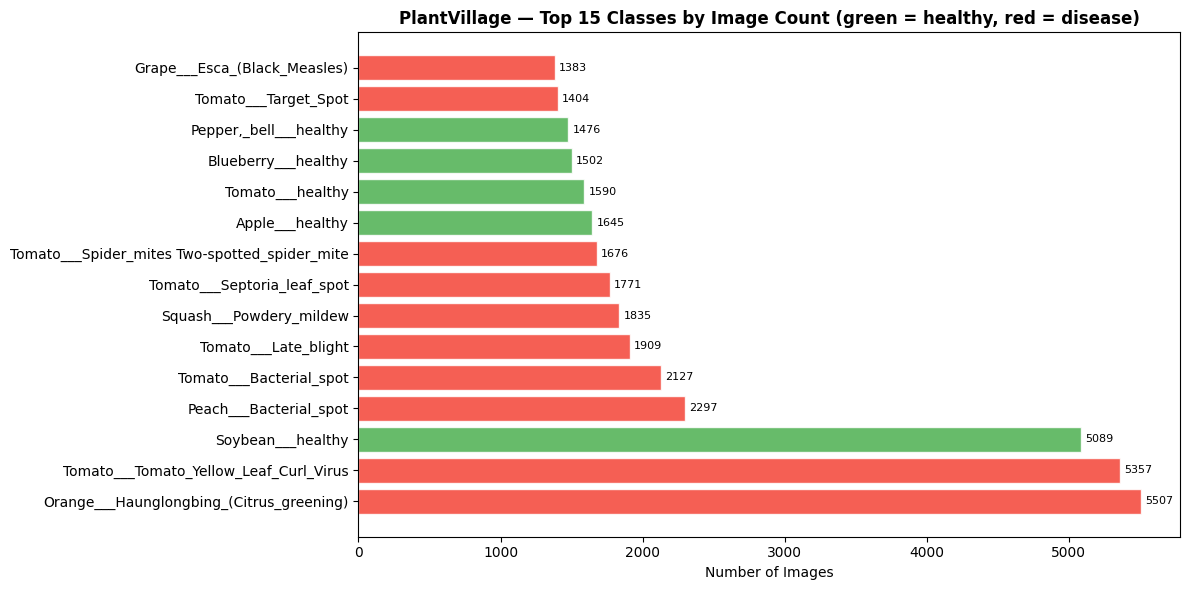

Plot saved to results/eda_plantvillage.png


In [3]:
import pathlib, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

RESULTS = Path("../results")
RESULTS.mkdir(exist_ok=True)

pv_dir = PLANTVILLAGE_IMAGES_DIR

if pv_dir.exists() and any(pv_dir.iterdir()):
    class_counts = {d.name: len(list(d.glob("*")))
                    for d in sorted(pv_dir.iterdir()) if d.is_dir()}
    print(f"Dataset: {pv_dir}")
    print(f"Classes: {len(class_counts)} | Images: {sum(class_counts.values()):,}")
else:
    raise FileNotFoundError("PlantVillage dataset directory not found or empty. Ensure Section 2 ran successfully to set PLANTVILLAGE_IMAGES_DIR.")

top = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True)[:15])
colors = ["#4CAF50" if "healthy" in k.lower() else "#F44336" for k in top]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(list(top.keys()), list(top.values()), color=colors, alpha=0.85, edgecolor="white")
ax.set_xlabel("Number of Images")
ax.set_title("PlantVillage — Top 15 Classes by Image Count (green = healthy, red = disease)",
             fontweight="bold")
ax.bar_label(bars, padding=3, fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS / "eda_plantvillage.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Plot saved to results/eda_plantvillage.png")

## 4. Sample Image Grid (PlantVillage)

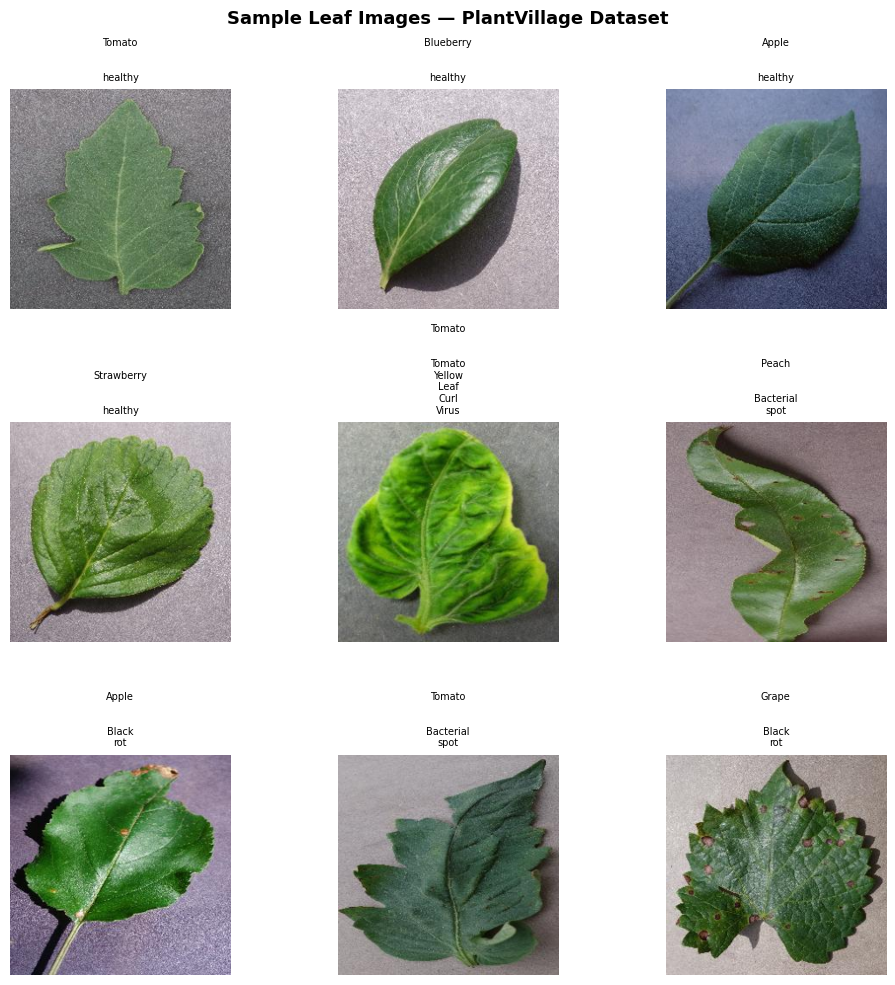

Image grid (real PlantVillage images) saved to results/sample_images.png


In [4]:
import random, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

pv_dir = PLANTVILLAGE_IMAGES_DIR
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle("Sample Leaf Images — PlantVillage Dataset", fontsize=13, fontweight="bold")

all_images = list(pv_dir.rglob("*.jpg")) + list(pv_dir.rglob("*.JPG")) if pv_dir.exists() else []

for i, ax in enumerate(axes.flat):
    if all_images:
        img_path = random.choice(all_images)
        img = Image.open(img_path).resize((224, 224))
        ax.imshow(img)
        label = img_path.parent.name.replace("_", "\n")
    else:
        # Synthetic placeholder: colored square with label
        color = np.random.uniform(0.1, 0.9, (224, 224, 3))
        color[:, :, 1] = color[:, :, 1] * 0.6 + 0.2  # greenish tint
        ax.imshow(color)
        labels = ["Tomato_healthy", "Tomato_Early_blight", "Potato_Late_blight",
                  "Corn_healthy", "Apple_scab", "Grape_Black_rot",
                  "Pepper_healthy", "Corn_Common_rust", "Potato_healthy"]
        label = labels[i].replace("_", "\n")
    ax.set_title(label, fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.savefig("../results/sample_images.png", dpi=100, bbox_inches="tight")
plt.show()
note = "(synthetic placeholders)" if not all_images else "(real PlantVillage images)"
print(f"Image grid {note} saved to results/sample_images.png")

---

## 5. Disease Classifier — Data Loading

Loads PlantVillage images using PyTorch `ImageFolder` and splits into train (80%) / val (20%).

**Known limitations to keep in mind when reading results:**
- **Class imbalance:** 21x ratio (Tomato_YellowLeaf_Curl_Virus: 6,416 images vs Potato_healthy: 304). Top-line accuracy is misleading — evaluate per-class (Section 9).
- **Random split:** PlantVillage contains near-duplicate images from the same leaf session. A random split likely places near-duplicates in both train and val, inflating reported accuracy.
- **Lab images only:** all photos are staged on uniform backgrounds. Field performance will be lower, especially for visually similar diseases.

> **Tip:** Enable GPU in Colab → Runtime → Change runtime type → T4 GPU.

In [5]:
import sys, torch, shutil
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from pathlib import Path
from collections import Counter

sys.path.insert(0, str(Path('../src').resolve()))

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

PV_DIR = PLANTVILLAGE_IMAGES_DIR

if not PV_DIR.exists() or not any(PV_DIR.iterdir()):
    raise FileNotFoundError(
        f'PlantVillage dataset directory not found or empty at {PV_DIR}. '
        'Run Section 2 first.'
    )
print(f'Using dataset: {PV_DIR}')

# Remove hidden/system directories that ImageFolder would mistake for classes
for d in PV_DIR.iterdir():
    if d.is_dir() and d.name.startswith('.'):
        print(f'Removing hidden directory: {d.name}')
        shutil.rmtree(d)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Two separate dataset instances so train/val each get their own transform.
# Sharing one instance and reassigning .transform mid-loop incorrectly affects both splits.
train_full = datasets.ImageFolder(PV_DIR, transform=train_transform)
val_full   = datasets.ImageFolder(PV_DIR, transform=val_transform)

CLASS_NAMES = train_full.classes
NUM_CLASSES = len(CLASS_NAMES)

# Deterministic 80/20 split
torch.manual_seed(42)
perm          = torch.randperm(len(train_full)).tolist()
n_val         = int(0.2 * len(train_full))
val_indices   = perm[:n_val]
train_indices = perm[n_val:]

train_ds = Subset(train_full, train_indices)
val_ds   = Subset(val_full,   val_indices)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# Report class distribution and imbalance
label_counts = Counter(train_full.targets[i] for i in train_indices)
most_cls  = CLASS_NAMES[max(label_counts, key=label_counts.get)]
least_cls = CLASS_NAMES[min(label_counts, key=label_counts.get)]
print(f'\nClasses : {NUM_CLASSES}')
print(f'Train   : {len(train_indices):,} images')
print(f'Val     : {n_val:,} images')
print(f'Imbalance: {max(label_counts.values())} (most) vs {min(label_counts.values())} (least)')
print(f'  Most : {most_cls}')
print(f'  Least: {least_cls}')

Using device: cuda
Using dataset: ../data/raw/gabrieldgf4
Removing hidden directory: .git

Classes : 39
Train   : 43,444 images
Val     : 10,861 images
Imbalance: 4403 (most) vs 3 (least)
  Most : Orange___Haunglongbing_(Citrus_greening)
  Least: x_Removed_from_Healthy_leaves


## 6. Build ResNet-18 Disease Classifier

In [6]:
import torch.nn as nn
from torchvision import models

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params : {trainable:,}  /  {total:,} total")
print(f"Model ready on   : {DEVICE}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s]


Trainable params : 20,007  /  11,196,519 total
Model ready on   : cuda


## 7. Train ResNet-18 Disease Classifier

In [7]:
EPOCHS = 10
history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    # Training
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc  = correct / total

    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            preds  = model(images).argmax(1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)
    val_acc = val_correct / val_total

    scheduler.step()
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch}/{EPOCHS}  loss={train_loss:.4f}  '
          f'train_acc={train_acc:.3f}  val_acc={val_acc:.3f}')

Epoch 1/10  loss=0.6849  train_acc=0.837  val_acc=0.925
Epoch 2/10  loss=0.2792  train_acc=0.920  val_acc=0.936
Epoch 3/10  loss=0.2295  train_acc=0.930  val_acc=0.948
Epoch 4/10  loss=0.1907  train_acc=0.941  val_acc=0.949
Epoch 5/10  loss=0.1843  train_acc=0.942  val_acc=0.949
Epoch 6/10  loss=0.1757  train_acc=0.945  val_acc=0.950
Epoch 7/10  loss=0.1607  train_acc=0.950  val_acc=0.954
Epoch 8/10  loss=0.1622  train_acc=0.949  val_acc=0.954
Epoch 9/10  loss=0.1579  train_acc=0.951  val_acc=0.955
Epoch 10/10  loss=0.1546  train_acc=0.951  val_acc=0.955


## 8. Training Curves & Save Model

The top-line `val_acc` here is averaged over all classes — misleading given the 21x imbalance. See **Section 9** for the per-class breakdown and honest interpretation.

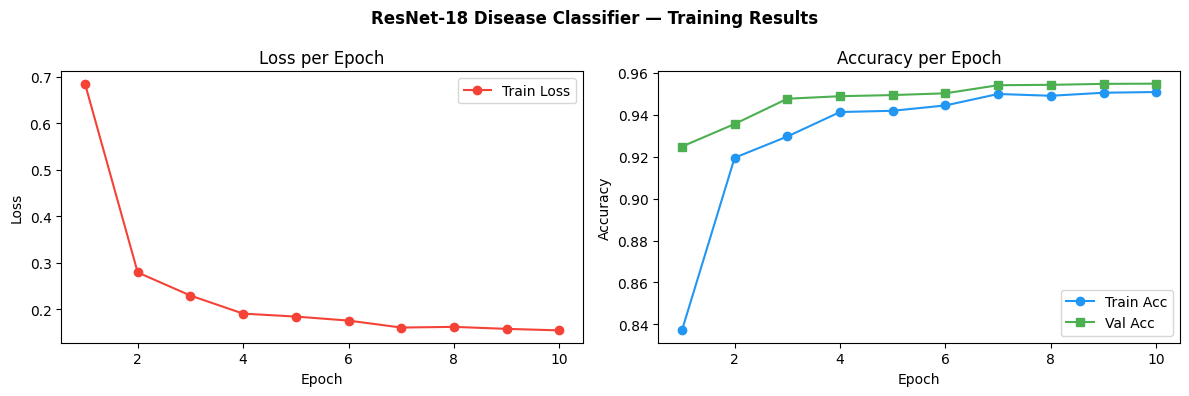

Model saved → results/disease_model.pth
Final val accuracy: 0.955


In [8]:
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS = Path("../results")
RESULTS.mkdir(exist_ok=True)
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("ResNet-18 Disease Classifier — Training Results", fontweight="bold")

axes[0].plot(epochs_range, history["train_loss"], marker="o", color="#F44336", label="Train Loss")
axes[0].set_title("Loss per Epoch"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker="o", color="#2196F3", label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"],   marker="s", color="#4CAF50", label="Val Acc")
axes[1].set_title("Accuracy per Epoch"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS / "disease_training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

torch.save({
    "model_state": model.state_dict(),
    "classes":     CLASS_NAMES,
    "model_type":  "resnet18",
}, RESULTS / "disease_model.pth")
print(f"Model saved → results/disease_model.pth")
print(f"Final val accuracy: {history['val_acc'][-1]:.3f}")

---

## 8B. Unfrozen Backbone — layer4 Fine-Tuning

The frozen-backbone baseline (Sections 6–8) trains only the 20K-parameter FC head. This section unfreezes the final residual block (`layer4`, ~2.1M parameters) and fine-tunes it alongside the FC head using **differential learning rates**:

- `layer4` → lr = 1e-4 (low, to avoid destroying pretrained features)
- FC head  → lr = 1e-3 (same as baseline)

**Why this might help:** The diseases most confused by the frozen model (Corn Cercospora vs Northern Leaf Blight, Tomato Early vs Late blight) differ mainly in texture — exactly what layer4 encodes. Adapting those weights to plant disease patterns should reduce within-crop confusion.

**Note:** This section trains a second model from scratch. The frozen baseline is untouched and already saved in `results/disease_model.pth`.

In [ ]:
import torch.nn as nn
from torchvision import models

model_unf = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze all layers first
for param in model_unf.parameters():
    param.requires_grad = False

# Unfreeze layer4 (final residual block, ~2.1M params)
for param in model_unf.layer4.parameters():
    param.requires_grad = True

# Replace FC head for our classes
model_unf.fc = nn.Linear(model_unf.fc.in_features, NUM_CLASSES)
model_unf = model_unf.to(DEVICE)

# Differential learning rates: lower lr for layer4 to avoid catastrophic forgetting
optimizer_unf = torch.optim.Adam([
    {"params": model_unf.layer4.parameters(), "lr": 1e-4},
    {"params": model_unf.fc.parameters(),     "lr": 1e-3},
])
criterion_unf = nn.CrossEntropyLoss()
scheduler_unf = torch.optim.lr_scheduler.StepLR(optimizer_unf, step_size=3, gamma=0.5)

trainable_unf = sum(p.numel() for p in model_unf.parameters() if p.requires_grad)
total_unf     = sum(p.numel() for p in model_unf.parameters())
print(f"Trainable params : {trainable_unf:,}  /  {total_unf:,} total")
print(f"  Frozen baseline : 20,007 trainable")
print(f"  This model      : {trainable_unf:,} trainable (layer4 + FC head)")

In [ ]:
EPOCHS_UNF   = 10
history_unf  = {'train_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, EPOCHS_UNF + 1):
    model_unf.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer_unf.zero_grad()
        outputs = model_unf(images)
        loss    = criterion_unf(outputs, labels)
        loss.backward()
        optimizer_unf.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc  = correct / total

    model_unf.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            preds  = model_unf(images).argmax(1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)
    val_acc = val_correct / val_total

    scheduler_unf.step()
    history_unf['train_loss'].append(train_loss)
    history_unf['train_acc'].append(train_acc)
    history_unf['val_acc'].append(val_acc)
    print(f'Epoch {epoch}/{EPOCHS_UNF}  loss={train_loss:.4f}  '
          f'train_acc={train_acc:.3f}  val_acc={val_acc:.3f}')

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS = Path('../results')
epochs_range = range(1, EPOCHS_UNF + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Frozen vs Unfrozen Backbone — Training Comparison", fontweight="bold")

axes[0].plot(epochs_range, history['train_loss'],     marker='o', color='#F44336',
             linestyle='--', label='Frozen train loss')
axes[0].plot(epochs_range, history_unf['train_loss'], marker='o', color='#FF9800',
             label='Unfrozen train loss')
axes[0].set_title("Train Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history['val_acc'],     marker='s', color='#4CAF50',
             linestyle='--', label=f'Frozen val acc ({history["val_acc"][-1]:.3f})')
axes[1].plot(epochs_range, history_unf['val_acc'], marker='s', color='#2196F3',
             label=f'Unfrozen val acc ({history_unf["val_acc"][-1]:.3f})')
axes[1].set_title("Val Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS / 'frozen_vs_unfrozen.png', dpi=120, bbox_inches='tight')
plt.show()

# Save unfrozen model
torch.save({
    "model_state": model_unf.state_dict(),
    "classes":     CLASS_NAMES,
    "model_type":  "resnet18_layer4_unfrozen",
}, RESULTS / "disease_model_unfrozen.pth")

print(f"\nFrozen baseline  final val acc : {history['val_acc'][-1]:.3f}")
print(f"Unfrozen model   final val acc : {history_unf['val_acc'][-1]:.3f}")
print(f"\nUnfrozen model saved to results/disease_model_unfrozen.pth")
print("\nNote: both numbers are inflated by near-duplicate images in the random split.")
print("The per-class breakdown (Section 9) tells the fuller story.")

## 9. Per-Class Evaluation & Error Analysis

Top-line accuracy hides the class imbalance. This section breaks accuracy down by class so failures are visible.

**Lab-to-field caveat:** these results come from PlantVillage lab images — uniform backgrounds, controlled lighting, isolated leaves. In real field conditions expect lower accuracy, particularly for:
- Classes with few samples (Potato_healthy: ~304 images total)
- Visually similar diseases (Early blight vs Late blight, Bacterial spot vs Septoria)
- Any class where the model has seen limited visual variation

This caveat belongs in the interpretation of classifier results, not only in the discussion section.

In [9]:
import numpy as np
from pathlib import Path

RESULTS = Path('../results')
RESULTS.mkdir(exist_ok=True)

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        preds  = model(images).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"{'Class':<52} {'Correct':>7} {'Total':>7}  {'Acc':>6}")
print('-' * 78)
per_class_stats = []
for i, cls in enumerate(CLASS_NAMES):
    mask    = all_labels == i
    total   = mask.sum()
    correct = (all_preds[mask] == i).sum()
    acc     = correct / total if total > 0 else 0.0
    per_class_stats.append((cls, int(correct), int(total), acc))

for cls, correct, total, acc in sorted(per_class_stats, key=lambda x: x[3]):
    flag = '  <- low' if acc < 0.70 else ''
    print(f'  {cls:<50} {correct:>7} {total:>7}  {acc:.3f}{flag}')

overall = (all_preds == all_labels).mean()
print(f'\nOverall val accuracy : {overall:.3f}')
print('\nNote: classes with few val samples have high variance in this metric.')
print('Low accuracy on small classes is expected and must be stated explicitly in the report.')

Class                                                Correct   Total     Acc
------------------------------------------------------------------------------
  x_Removed_from_Healthy_leaves                            0       2  0.000  <- low
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      74     105  0.705
  Tomato___Early_blight                                  147     205  0.717
  Tomato___Tomato_mosaic_virus                            65      82  0.793
  Tomato___Target_Spot                                   265     306  0.866
  Tomato___Late_blight                                   336     383  0.877
  Tomato___Septoria_leaf_spot                            300     340  0.882
  Potato___healthy                                        24      27  0.889
  Tomato___Leaf_Mold                                     169     190  0.889
  Tomato___Spider_mites Two-spotted_spider_mite          296     328  0.902
  Apple___Apple_scab                                     119     130  0.915


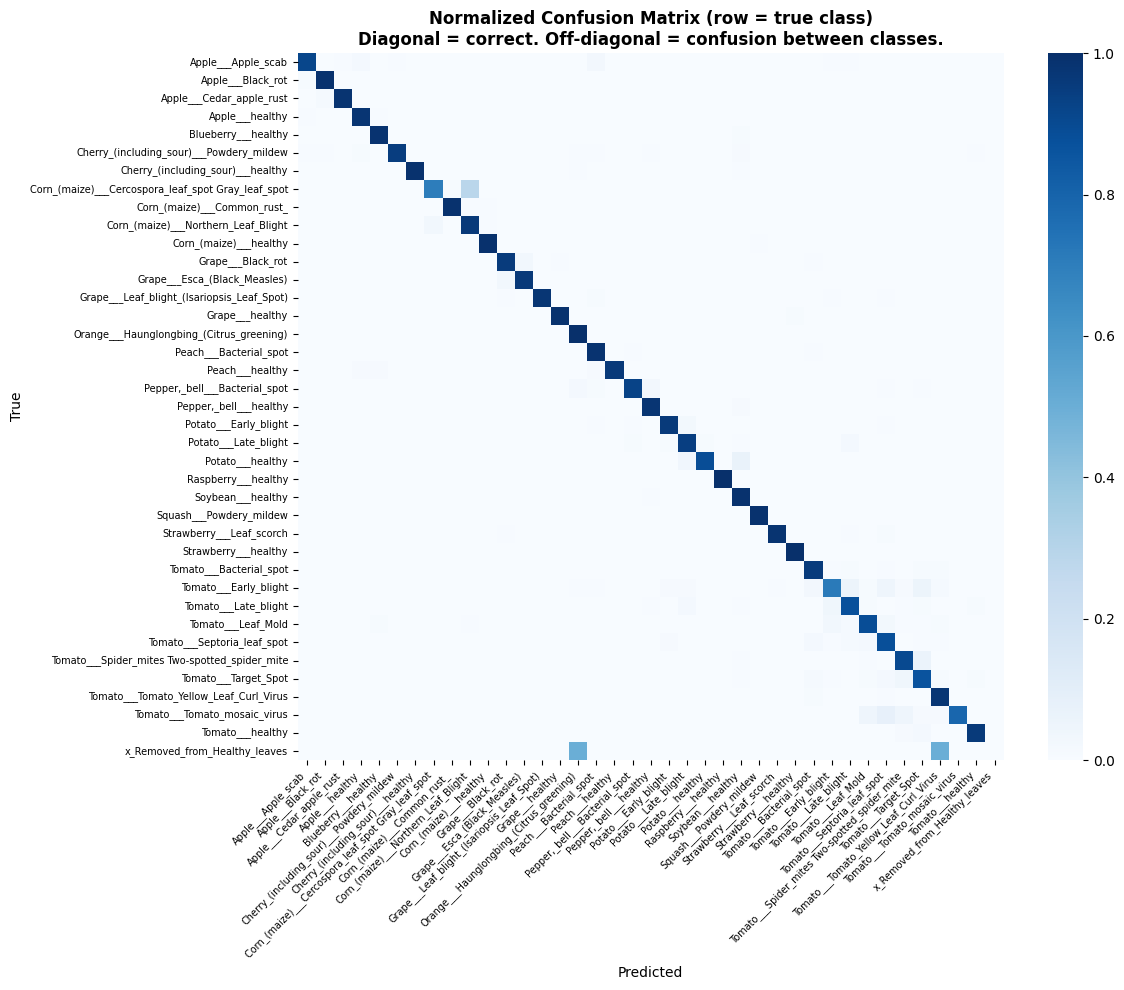

Saved to results/confusion_matrix.png

Top 5 most confused class pairs (true -> predicted, count):
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot -> Corn_(maize)___Northern_Leaf_Blight  (30 images)
  Tomato___Spider_mites Two-spotted_spider_mite -> Tomato___Target_Spot  (20 images)
  Tomato___Late_blight -> Tomato___Early_blight  (16 images)
  Tomato___Target_Spot -> Tomato___Spider_mites Two-spotted_spider_mite  (12 images)
  Tomato___Early_blight -> Tomato___Target_Spot  (12 images)


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm_norm, annot=False, cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax, vmin=0, vmax=1,
)
ax.set_xlabel('Predicted', fontsize=10)
ax.set_ylabel('True',      fontsize=10)
ax.set_title(
    'Normalized Confusion Matrix (row = true class)\n'
    'Diagonal = correct. Off-diagonal = confusion between classes.',
    fontweight='bold',
)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig(RESULTS / 'confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to results/confusion_matrix.png')

# Report most confused pairs
pairs = [
    (cm[i, j], CLASS_NAMES[i], CLASS_NAMES[j])
    for i in range(len(CLASS_NAMES))
    for j in range(len(CLASS_NAMES))
    if i != j
]
pairs.sort(reverse=True)
print('\nTop 5 most confused class pairs (true -> predicted, count):')
for count, true_cls, pred_cls in pairs[:5]:
    print(f'  {true_cls} -> {pred_cls}  ({count} images)')

---

## 10. Environmental Risk Model — Decision Support Layer

> **What this model is and is not**
>
> The risk score used as the training target is **not observed field data**. It is computed algorithmically by `fusion.py` — a weighted formula combining a per-class severity lookup, weather conditions, and classifier confidence:
>
> `risk_score = severity_base(class) × 0.4 + confidence × 0.3 + env_score(temp, humidity, rain) × 0.3`
>
> XGBoost is trained to approximate that deterministic formula.
>
> **Why the R² looks high:** it is expected and does not measure real-world validity. It measures how well XGBoost reproduces the formula it was given. The `disease_class` feature dominates (~67% importance) because `severity_base` is a fixed per-class value — not because the model learned anything from field observations.
>
> **What this layer actually does:** packages the rule-based formula into a portable scorer that runs at inference. It adds practical decision-support value, but must be described as a rule approximator, not a learned multimodal model. The report must be explicit that the target is derived and state what agronomic assumptions are built into it.

Generates synthetic (disease, weather) pairs, computes derived risk labels via `fusion.py`, then trains XGBoost to approximate the formula.

In [17]:
import numpy as np, pandas as pd

# --- Definitions moved here for robustness ---
DISEASE_CONDITIONS = {
    "fungal": {
        "classes": [
            "Apple___Apple_scab", "Apple___Black_rot", "Apple___Cedar_apple_rust",
            "Cherry_(including_sour)___Powdery_mildew", "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
            "Corn_(maize)___Common_rust_", "Grape___Black_rot", "Grape___Esca_(Black_Measles)",
            "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)", "Potato___Early_blight",
            "Potato___Late_blight", "Squash___Powdery_mildew", "Strawberry___Leaf_scorch",
            "Tomato___Early_blight", "Tomato___Late_blight", "Tomato___Leaf_Mold",
            "Tomato___Septoria_leaf_spot", "Peach___Bacterial_spot"
        ],
        "environmental_factors": {
            "temperature_optimum": 25, "temperature_range": 5,
            "humidity_optimum": 85, "humidity_range": 10,
            "rain_factor": 1.5
        }
    },
    "bacterial": {
        "classes": [
            "Pepper,_bell___Bacterial_spot", "Tomato___Bacterial_spot"
        ],
        "environmental_factors": {
            "temperature_optimum": 30, "temperature_range": 5,
            "humidity_optimum": 70, "humidity_range": 10,
            "rain_factor": 2.0
        }
    },
    "viral": {
        "classes": [
            "Tomato___Tomato_Yellow_Leaf_Curl_Virus", "Tomato___Tomato_mosaic_virus",
            "Orange___Haunglongbing_(Citrus_greening)"
        ],
        "environmental_factors": {
            "temperature_optimum": 35, "temperature_range": 5,
            "humidity_optimum": 50, "humidity_range": 15,
            "rain_factor": 0.5
        }
    },
    "mites": {
        "classes": [
            "Tomato___Spider_mites Two-spotted_spider_mite"
        ],
        "environmental_factors": {
            "temperature_optimum": 35, "temperature_range": 5,
            "humidity_optimum": 40, "humidity_range": 10,
            "rain_factor": 0.2
        }
    },
    "healthy": {
        "classes": [
            "Apple___healthy", "Blueberry___healthy", "Cherry_(including_sour)___healthy",
            "Corn_(maize)___healthy", "Grape___healthy", "Peach___healthy",
            "Pepper,_bell___healthy", "Potato___healthy", "Raspberry___healthy",
            "Soybean___healthy", "Strawberry___healthy", "Tomato___healthy",
            "x_Removed_from_Healthy_leaves"
        ],
         "environmental_factors": {
            "temperature_optimum": 25, "temperature_range": 10,
            "humidity_optimum": 60, "humidity_range": 20,
            "rain_factor": 1.0
        }
    }
}

RECOMMENDATIONS = {
    "Apple___healthy": {"severity": 0.0, "recommendation": "Maintain good cultural practices."},
    "Blueberry___healthy": {"severity": 0.0, "recommendation": "Maintain good cultural practices."},
    "Cherry_(including_sour)___healthy": {"severity": 0.0, "recommendation": "Maintain good cultural practices."},
    "Corn_(maize)___healthy": {"severity": 0.0, "recommendation": "Maintain good cultural practices."},
    "Grape___healthy": {"severity": 0.0, "recommendation": "Maintain good cultural practices."},
    "Peach___healthy": {"severity": 0.0, "recommendation": "Maintain good cultural practices."},
    "Pepper,_bell___healthy": {"severity": 0.0, "recommendation": "Maintain good cultural practices."},
    "Potato___healthy": {"severity": 0.0, "recommendation": "Maintain good cultural practices."},
    "Raspberry___healthy": {"severity": 0.0, "recommendation": "Maintain good cultural practices."},
    "Soybean___healthy": {"severity": 0.0, "recommendation": "Maintain good cultural practices."},
    "Strawberry___healthy": {"severity": 0.0, "recommendation": "Maintain good cultural practices."},
    "Tomato___healthy": {"severity": 0.0, "recommendation": "Maintain good cultural practices."},
    "Apple___Apple_scab": {"severity": 0.6, "recommendation": "Apply fungicides; prune infected branches."},
    "Apple___Black_rot": {"severity": 0.7, "recommendation": "Remove mummified fruit; apply fungicides."},
    "Apple___Cedar_apple_rust": {"severity": 0.4, "recommendation": "Remove cedar hosts; apply fungicides."},
    "Cherry_(including_sour)___Powdery_mildew": {"severity": 0.5, "recommendation": "Apply fungicides; improve air circulation."},
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": {"severity": 0.6, "recommendation": "Use resistant varieties; rotate crops."},
    "Corn_(maize)___Common_rust_": {"severity": 0.4, "recommendation": "Use resistant varieties; consider fungicides if severe."},
    "Corn_(maize)___Northern_Leaf_Blight": {"severity": 0.7, "recommendation": "Use resistant varieties; apply fungicides."},
    "Grape___Black_rot": {"severity": 0.8, "recommendation": "Apply fungicides; remove infected plant parts."},
    "Grape___Esca_(Black_Measles)": {"severity": 0.9, "recommendation": "Prune out diseased wood; no chemical cure."},
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)": {"severity": 0.5, "recommendation": "Apply fungicides; improve air circulation."},
    "Orange___Haunglongbing_(Citrus_greening)": {"severity": 1.0, "recommendation": "Remove infected trees; control psyllid vectors."},
    "Peach___Bacterial_spot": {"severity": 0.7, "recommendation": "Use resistant varieties; copper sprays."},
    "Pepper,_bell___Bacterial_spot": {"severity": 0.6, "recommendation": "Use disease-free seeds; copper sprays."},
    "Potato___Early_blight": {"severity": 0.6, "recommendation": "Apply fungicides; rotate crops."},
    "Potato___Late_blight": {"severity": 0.9, "recommendation": "Apply fungicides preventively; destroy infected plants."},
    "Squash___Powdery_mildew": {"severity": 0.5, "recommendation": "Apply fungicides; use resistant varieties."},
    "Strawberry___Leaf_scorch": {"severity": 0.5, "recommendation": "Improve drainage; apply fungicides."},
    "Tomato___Bacterial_spot": {"severity": 0.7, "recommendation": "Use disease-free seeds; copper sprays."},
    "Tomato___Early_blight": {"severity": 0.6, "recommendation": "Apply fungicides; rotate crops."},
    "Tomato___Late_blight": {"severity": 0.9, "recommendation": "Apply fungicides preventively; destroy infected plants."},
    "Tomato___Leaf_Mold": {"severity": 0.5, "recommendation": "Improve air circulation; apply fungicides."},
    "Tomato___Septoria_leaf_spot": {"severity": 0.5, "recommendation": "Remove infected leaves; apply fungicides."},
    "Tomato___Spider_mites Two-spotted_spider_mite": {"severity": 0.8, "recommendation": "Apply miticides; strong water sprays."},
    "Tomato___Target_Spot": {"severity": 0.6, "recommendation": "Apply fungicides; rotate crops."},
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": {"severity": 1.0, "recommendation": "Control whiteflies; remove infected plants."},
    "Tomato___Tomato_mosaic_virus": {"severity": 0.8, "recommendation": "Remove infected plants; sanitize tools."},
    "x_Removed_from_Healthy_leaves": {"severity": 0.1, "recommendation": "Investigate cause of removal."}
}

def _calculate_env_score(disease_type_info, temp, humidity, days_since_rain):
    temp_opt = disease_type_info["temperature_optimum"]
    temp_rng = disease_type_info["temperature_range"]
    hum_opt = disease_type_info["humidity_optimum"]
    hum_rng = disease_type_info["humidity_range"]
    rain_factor = disease_type_info["rain_factor"]

    temp_score = max(0, 1 - abs(temp - temp_opt) / temp_rng)
    hum_score = max(0, 1 - abs(humidity - hum_opt) / hum_rng)

    if rain_factor > 1: # Indicates disease benefits from rain (e.g., fungal, bacterial)
        rain_score = 1 - (days_since_rain / 30) # More recent rain (lower days_since_rain) -> higher score
    else: # Indicates disease benefits from dry conditions (e.g., mites, viral)
        rain_score = (days_since_rain / 30) # More recent rain (lower days_since_rain) -> lower score

    rain_score = max(0, min(1, rain_score * rain_factor)) # Scale by factor and clip

    env_score = (temp_score + hum_score + rain_score) / 3
    return env_score

def assess_risk(disease_class, confidence, severity_base, temp, humidity, days_since_rain):
    """
    Calculates a risk score based on disease, confidence, severity, and environmental factors.
    risk_score = severity_base(class) \u00d7 0.4 + confidence \u00d7 0.3 + env_score(temp, humidity, rain) \u00d7 0.3
    """
    disease_type_key = "healthy"
    for dtype, info in DISEASE_CONDITIONS.items():
        if disease_class in info["classes"]:
            disease_type_key = dtype
            break

    type_info = DISEASE_CONDITIONS[disease_type_key]["environmental_factors"]
    env_score = _calculate_env_score(type_info, temp, humidity, days_since_rain)

    risk_score = (severity_base * 0.4) + (confidence * 0.3) + (env_score * 0.3)

    risk_score = max(0.0, min(1.0, risk_score))

    return {
        "risk_score": risk_score,
        "environmental_score": env_score,
        "severity_base": severity_base,
        "confidence": confidence,
        "disease_type": disease_type_key,
    }
# --- End of definitions ---

np.random.seed(42)
N_PER_CLASS = 500   # samples per disease class

# Weather sampling ranges per disease type (mirrors WeatherAugmentedDataset)
WEATHER_BIAS = {
    "fungal":    dict(temp=(23,4),  humidity=(82,8),  rain=(1.5,1.0)),
    "bacterial": dict(temp=(26,4),  humidity=(76,8),  rain=(2.0,1.5)),
    "viral":     dict(temp=(32,4),  humidity=(38,12), rain=(9.0,3.0)),
    "mite":      dict(temp=(35,4),  humidity=(30,10), rain=(10.0,3.0)),
    "healthy":   dict(temp=(22,5),  humidity=(60,12), rain=(4.0,2.0)),
}

FUNGAL    = {c for dtype, info in DISEASE_CONDITIONS.items() if dtype == "fungal"    for c in info["classes"]}
BACTERIAL = {c for dtype, info in DISEASE_CONDITIONS.items() if dtype == "bacterial" for c in info["classes"]}
VIRAL     = {c for dtype, info in DISEASE_CONDITIONS.items() if dtype == "viral"     for c in info["classes"]}
MITE      = {c for dtype, info in DISEASE_CONDITIONS.items() if dtype == "mites"     for c in info["classes"]}

def disease_type(cls):
    if cls in FUNGAL:    return "fungal"
    if cls in BACTERIAL: return "bacterial"
    if cls in VIRAL:     return "viral"
    if cls in MITE:      return "mite"
    return "healthy"

ALL_CLASSES = list(RECOMMENDATIONS.keys())

rows = []
for cls in ALL_CLASSES:
    dtype   = disease_type(cls)
    bias    = WEATHER_BIAS[dtype]
    severity = RECOMMENDATIONS[cls]["severity"]

    for _ in range(N_PER_CLASS):
        temp     = float(np.clip(np.random.normal(*bias["temp"]),     -10, 50))
        humidity = float(np.clip(np.random.normal(*bias["humidity"]),   0, 100))
        rain     = float(np.clip(np.random.normal(*bias["rain"]),       0,  30))
        confidence = float(np.clip(np.random.beta(8, 2), 0.4, 1.0))   # realistic softmax dist

        risk = assess_risk(cls, confidence, severity, temp, humidity, rain)
        rows.append({
            "disease_class": cls,
            "temperature":   temp,
            "humidity":      humidity,
            "days_since_rain": rain,
            "confidence":    confidence,
            "risk_score":    risk["risk_score"],
        })

df = pd.DataFrame(rows)
print(f"Dataset: {df.shape}  |  classes: {df['disease_class'].nunique()}")
print(df.groupby("disease_class")["risk_score"].mean().round(3).to_string())

Dataset: (19500, 6)  |  classes: 39
disease_class
Apple___Apple_scab                                    0.665
Apple___Black_rot                                     0.702
Apple___Cedar_apple_rust                              0.580
Apple___healthy                                       0.364
Blueberry___healthy                                   0.360
Cherry_(including_sour)___Powdery_mildew              0.622
Cherry_(including_sour)___healthy                     0.361
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot    0.663
Corn_(maize)___Common_rust_                           0.582
Corn_(maize)___Northern_Leaf_Blight                   0.645
Corn_(maize)___healthy                                0.362
Grape___Black_rot                                     0.742
Grape___Esca_(Black_Measles)                          0.785
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)            0.620
Grape___healthy                                       0.365
Orange___Haunglongbing_(Citrus_greening)          

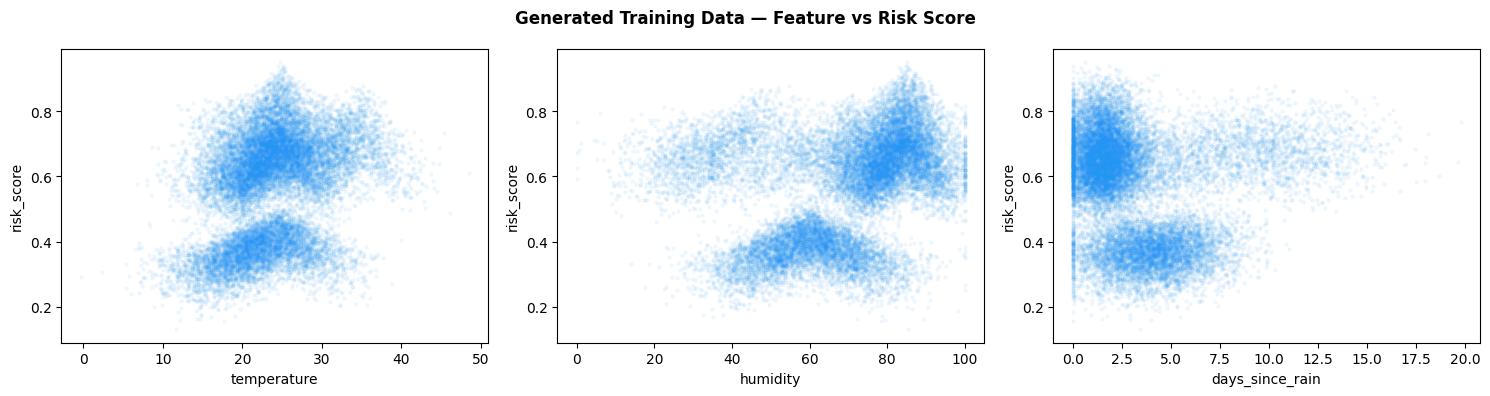

Risk score distribution:
count    19500.000
mean         0.566
std          0.161
min          0.131
25%          0.406
50%          0.607
75%          0.691
max          0.950
Name: risk_score, dtype: float64


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Generated Training Data — Feature vs Risk Score", fontweight="bold")

for ax, feat in zip(axes, ["temperature", "humidity", "days_since_rain"]):
    ax.scatter(df[feat], df["risk_score"], alpha=0.05, s=5, color="#2196F3")
    ax.set_xlabel(feat)
    ax.set_ylabel("risk_score")

plt.tight_layout()
plt.savefig(Path("../results") / "xgb_training_data.png", dpi=120, bbox_inches="tight")
plt.show()

print("Risk score distribution:")
print(df["risk_score"].describe().round(3))


## 11. Train XGBoost Risk Model

In [19]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

le = LabelEncoder()
df['class_enc'] = le.fit_transform(df['disease_class'])

FEATURES = ['temperature', 'humidity', 'days_since_rain', 'confidence', 'class_enc']
X = df[FEATURES].values
y = df['risk_score'].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model_xgb = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
model_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)

y_pred = model_xgb.predict(X_val)
print(f'\nVal MAE : {mean_absolute_error(y_val, y_pred):.4f}')
print(f'Val R2  : {r2_score(y_val, y_pred):.4f}')
print('\nNote: these metrics measure approximation of the derived formula,')
print('not prediction of observed field risk. High scores are expected and')
print('should not be interpreted as evidence of real-world validity.')

[0]	validation_0-rmse:0.15553
[50]	validation_0-rmse:0.08042
[100]	validation_0-rmse:0.05787
[150]	validation_0-rmse:0.04563
[200]	validation_0-rmse:0.03836
[250]	validation_0-rmse:0.03282
[299]	validation_0-rmse:0.02942

Val MAE : 0.0184
Val R2  : 0.9661

Note: these metrics measure approximation of the derived formula,
not prediction of observed field risk. High scores are expected and
should not be interpreted as evidence of real-world validity.


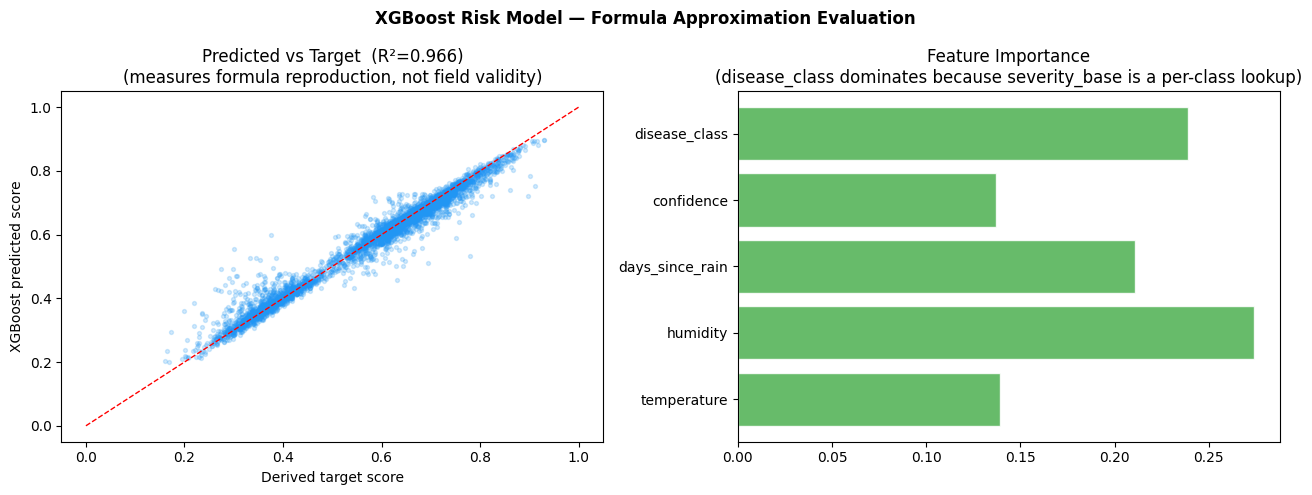

Saved to results/risk_model.pkl

Sanity checks (derived score — not real field risk):


In [20]:
import pickle, matplotlib.pyplot as plt
from pathlib import Path

RESULTS = Path('../results')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('XGBoost Risk Model — Formula Approximation Evaluation', fontweight='bold')

axes[0].scatter(y_val, y_pred, alpha=0.2, s=8, color='#2196F3')
lims = [0, 1]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('Derived target score')
axes[0].set_ylabel('XGBoost predicted score')
axes[0].set_title(
    f'Predicted vs Target  (R²={r2_score(y_val, y_pred):.3f})\n'
    '(measures formula reproduction, not field validity)'
)

feat_labels = ['temperature', 'humidity', 'days_since_rain', 'confidence', 'disease_class']
axes[1].barh(feat_labels, model_xgb.feature_importances_, color='#4CAF50', alpha=0.85, edgecolor='white')
axes[1].set_title(
    'Feature Importance\n'
    '(disease_class dominates because severity_base is a per-class lookup)'
)

plt.tight_layout()
plt.savefig(RESULTS / 'xgb_risk_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

# Save
with open(RESULTS / 'risk_model.pkl', 'wb') as f:
    pickle.dump({'model': model_xgb, 'label_encoder': le, 'features': FEATURES}, f)
print('Saved to results/risk_model.pkl')

print('\nSanity checks (derived score — not real field risk):')
for cls, temp, hum, rain, conf in [
    ('Tomato_Late_blight',  25, 90, 1, 0.95),
    ('Tomato_Early_blight', 20, 55, 5, 0.80),
    ('Tomato_healthy',      22, 60, 4, 0.99),
]:
    if cls in le.classes_:
        enc   = le.transform([cls])[0]
        score = model_xgb.predict([[temp, hum, rain, conf, enc]])[0]
        print(f'  {cls:<45} score={score:.3f}')